In [1]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch
import yaml

In [2]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [3]:
model = YOLO(config['model']['name'])

In [4]:
VEHICLE_CLASSES = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

In [5]:
import random
import os

In [6]:
image_folder = config['data']['frames_folder']
images = random.sample(os.listdir(image_folder), k=10)

Processing MVI_40152_img00076.jpg
Processing MVI_40981_img01727.jpg
Processing MVI_40131_img00852.jpg
Processing MVI_63561_img01116.jpg
Processing MVI_63544_img00645.jpg
Processing MVI_40751_img00857.jpg
Processing MVI_40191_img01501.jpg
Processing MVI_40161_img01317.jpg
Processing MVI_40211_img01448.jpg
Processing MVI_40712_img02162.jpg


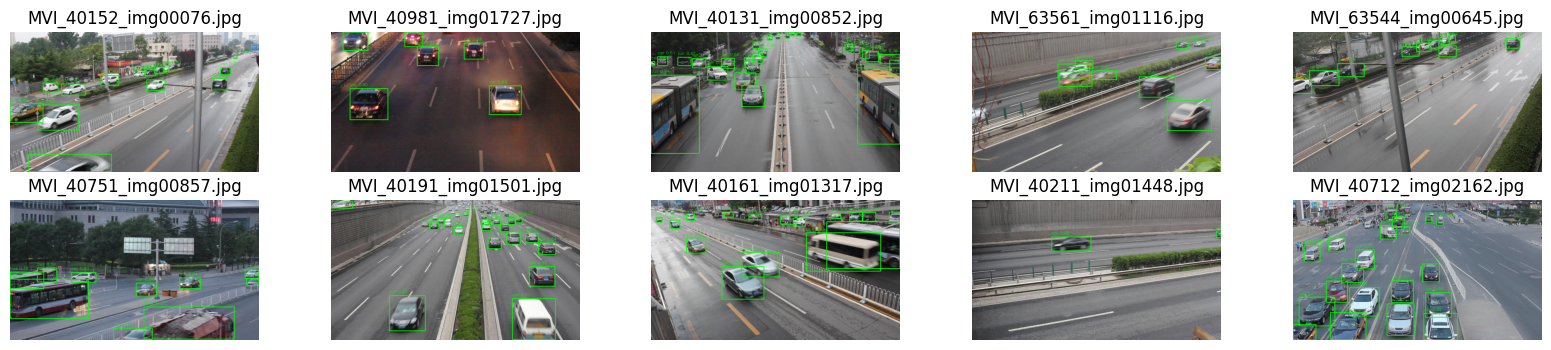

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 4))
for image in images:
    img_path = os.path.join(image_folder, image)
    img = cv2.imread(img_path)
    results = model(img_path, verbose=False)[0]
    print(f"Processing {image}")
    for result in results:
        cur_boxes = result.boxes
        for box in cur_boxes:
            cls_id = int(box.cls[0])
            if cls_id in VEHICLE_CLASSES:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                conf = box.conf.item()
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"{VEHICLE_CLASSES[cls_id]} {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes.flat[images.index(image)].imshow(img_rgb)
    axes.flat[images.index(image)].set_title(image)
    axes.flat[images.index(image)].axis('off')
plt.show()